# BRAIN TUMOUR DETECTION AND CLASSIFICATION USING CNN-BASED METHODS

### 💡 Note:

This notebook is designed to run within a Conda environment.
Please use the provided environment.yml file to recreate the exact same environment

### I. Importing essential libraries

In [10]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [11]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.applications import ResNet50, VGG16
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
import pickle

### II. Function: Loading and Preprocessing Image Data


In [12]:
# Function to load images and their corresponding labels using TensorFlow's Keras preprocessing image module.
def load_data(folder_path, label_mapping, image_size):
    images = []  # List to store images
    labels = []  # List to store labels
    for label in label_mapping:  # Loop through each label in the label mapping
        folder = os.path.join(folder_path, label)  # Path to the folder containing images for the current label
        for filename in os.listdir(folder):  # Loop through each image file in the folder
            img = cv2.imread(os.path.join(folder, filename))  # Read the image using OpenCV
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert the image to RGB format 
            img = cv2.resize(img, (image_size, image_size))  # Resize the image to the specified size

            # Preprocessing for noise reduction
            img = cv2.GaussianBlur(img, (5, 5), 0)  # Apply Gaussian blur

            img = img / 255.0  # Normalize pixel values to be between 0 and 1
            images.append(img)  # Append the image to the list of images
            labels.append(label_mapping[label])  # Append the corresponding label to the list of labels
    return np.array(images), np.array(labels)  # Convert lists to NumPy arrays and return them

In [ ]:
# Defining the label mapping for each tumour type to a numerical label for classification.
label_mapping = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

# Define image size
image_size = 224

# Loading the training data
train_folder = "./MRI_images/Training"
X_train, Y_train = load_data(train_folder, label_mapping, image_size)  # X_train contains images, Y_train contains labels
X_train, Y_train = shuffle(X_train, Y_train, random_state=101)  # Shuffle the training data

# Loading the testing data
test_folder = "./MRI_images/Testing"
X_test, Y_test = load_data(test_folder, label_mapping, image_size)  # X_test contains images, Y_test contains labels
X_test, Y_test = shuffle(X_test, Y_test, random_state=101)  # Shuffle the testing data

### III. Exploratory Data Analysis (EDA)


In [14]:
# Checking the lengths of X_train and X_test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5711, 224, 224, 3)
X_test shape: (1310, 224, 224, 3)


In [15]:
# Function to print the contents of a folder
def print_folder_contents(folder):
    # Get the list of contents in the folder
    contents = os.listdir(folder)
    
    # Print the number of items in the folder
    print(f"Number of items in {folder}:", len(contents))
    
    # Iterate through each item in the folder and print its name
    for item in contents:
        print(item)

# Printing the content of train_folder
print_folder_contents(train_folder)

# Printing contents of test_folder
print_folder_contents(test_folder)

Number of items in ./MRI_images/Training: 4
glioma
meningioma
notumor
pituitary
Number of items in ./MRI_images/Testing: 4
glioma
meningioma
notumor
pituitary


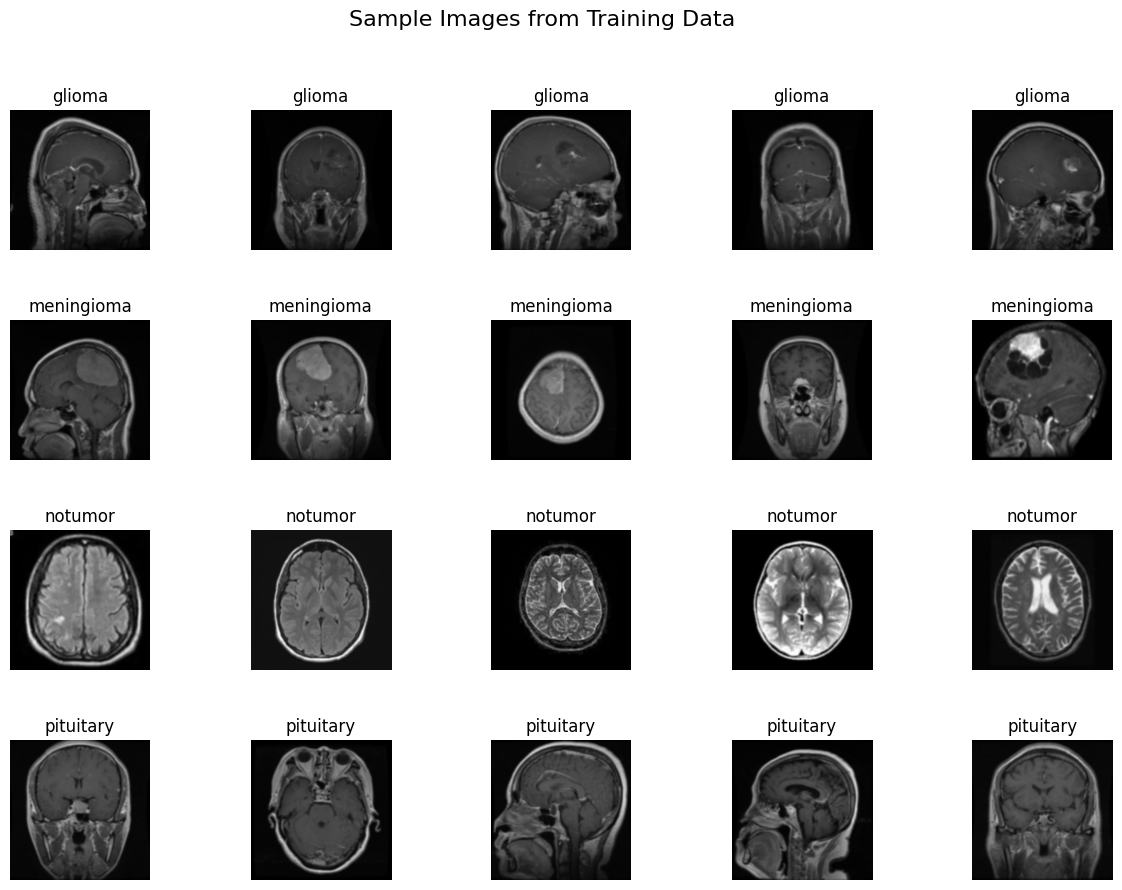

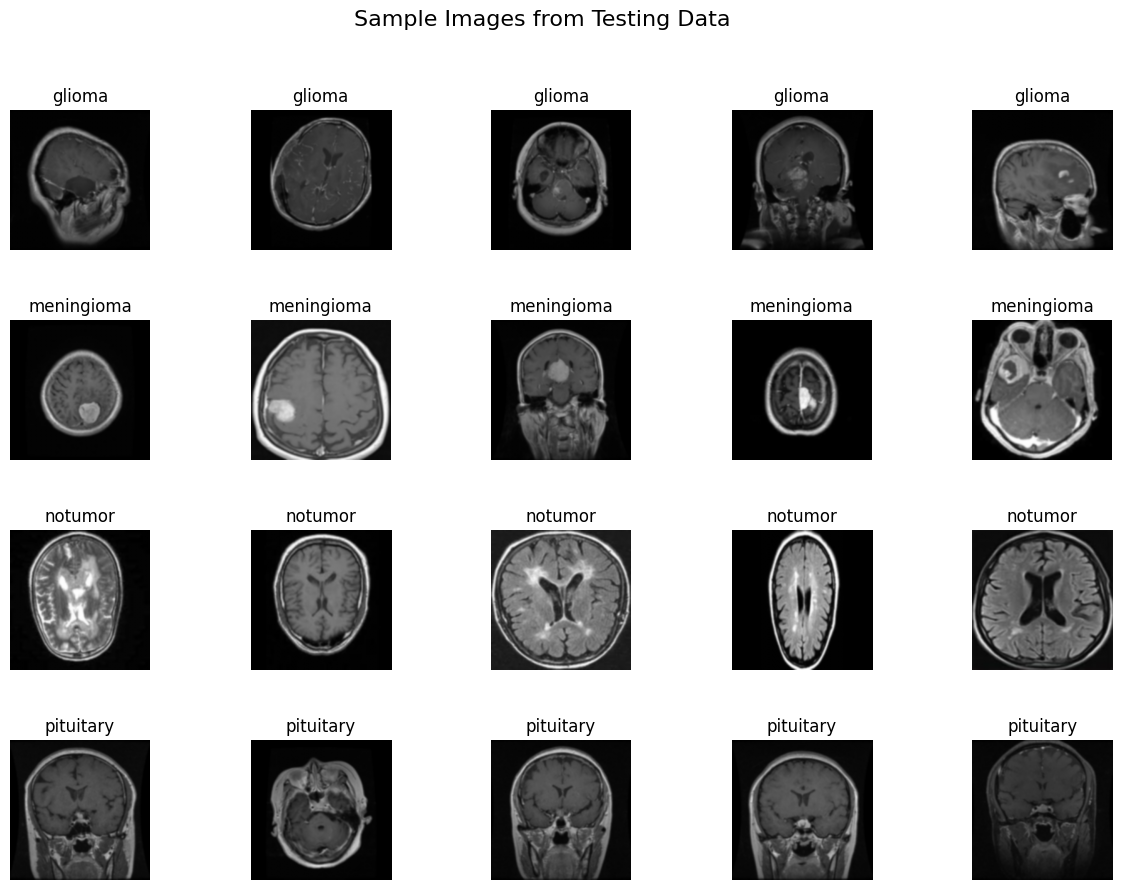

In [16]:
# Defining the function to load sample images from each class
def display_sample_images(X, Y, label_mapping, num_samples=5):
    # Create a figure and axes
    fig, axes = plt.subplots(len(label_mapping), num_samples, figsize=(15, 10))
    fig.subplots_adjust(hspace=0.5)
    
    # Iterate over each class
    for i, label in enumerate(label_mapping):
        class_indices = np.where(Y == label_mapping[label])[0]  # Indices of images belonging to this class
        sample_indices = np.random.choice(class_indices, num_samples, replace=False)  # Randomly select sample indices
        
        # Display sample images for this class
        for j, idx in enumerate(sample_indices):
            axes[i, j].imshow(X[idx])
            axes[i, j].set_title(label)
            axes[i, j].axis('off')

# Display sample images from training data
display_sample_images(X_train, Y_train, label_mapping)
plt.suptitle('Sample Images from Training Data', fontsize=16)
plt.show()

# Display sample images from testing data
display_sample_images(X_test, Y_test, label_mapping)
plt.suptitle('Sample Images from Testing Data', fontsize=16)
plt.show()

In [18]:
# Function to Check the class distribution in training and testing data
def check_class_distribution(X, Y, data_type="Training"):
    class_counts = Counter(Y)
    print('-----------------------------------------------')
    print(f"Class Distribution in {data_type} Data:")
    print(class_counts)

check_class_distribution(X_train, Y_train, data_type="Training")
check_class_distribution(X_test, Y_test, data_type="Testing")

-----------------------------------------------
Class Distribution in Training Data:
Counter({2: 1595, 3: 1456, 1: 1339, 0: 1321})
-----------------------------------------------
Class Distribution in Testing Data:
Counter({2: 405, 1: 306, 3: 300, 0: 299})


### IV. Data Balancing

In [19]:
# Oversample the training data using SMOTE
smote = SMOTE(random_state=101)

X_train_flat = X_train.reshape(-1, image_size * image_size * 3)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train_flat, Y_train)

# Reshape training data back to original shape
X_train_resampled = X_train_resampled.reshape(-1, image_size, image_size, 3)

# Check class distribution after oversampling
check_class_distribution(X_train_resampled, Y_train_resampled, data_type="Training After Oversampling")

-----------------------------------------------
Class Distribution in Training After Oversampling Data:
Counter({0: 1595, 1: 1595, 2: 1595, 3: 1595})


### V. Data Splitting

In [20]:
# Splitting the testing data into testing and validation sets
X_test, X_val, Y_test, Y_val = train_test_split(X_test, Y_test, test_size=0.5, random_state=101)

### VI. Data Augmentation

In [21]:
# Creating an ImageDataGenerator object for data augmentation
datagen = ImageDataGenerator(
  rotation_range=15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True
)

------------------------------------------------------------------------------------------------------------------------------------------------------------------

### VII. Baseline CNN Model


In [23]:
# Defining the baseline CNN model
model_basline = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax') 
])

In [24]:
# Compiling the model
model_basline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Displaying the model summary
model_basline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 197136)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    12,616,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,617,476 (48.13 MB)

 Trainable params: 12,617,476 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the model with data augmentation and the balanced data
history_basline = model_basline.fit(datagen.flow(X_train_resampled, Y_train_resampled, batch_size=32), epochs=25, validation_data=(X_val, Y_val))

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 218ms/step - accuracy: 0.3843 - loss: 1.3549 - val_accuracy: 0.6275 - val_loss: 0.9875
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 226ms/step - accuracy: 0.5475 - loss: 1.0511 - val_accuracy: 0.6733 - val_loss: 0.9317
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 232ms/step - accuracy: 0.6121 - loss: 0.9087 - val_accuracy: 0.6870 - val_loss: 0.7862
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 238ms/step - accuracy: 0.6343 - loss: 0.8446 - val_accuracy: 0.6718 - val_loss: 0.7795
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 237ms/step - accuracy: 0.6677 - loss: 0.8071 - val_accuracy: 0.7008 - val_loss: 0.7550
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 244ms/step - accuracy: 0.6489 - loss: 0.8121 - val_accuracy: 0.6809 - val_loss: 0.8391
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 239ms/step - accuracy: 0.6563 - loss: 0.7972 - val_accuracy: 0.6794 - val_loss: 0.8024
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 51s 246ms/step - accuracy: 0.6664 - loss: 0

----------------------------------------------------------------------------------------------------------------------------

### VIII. Saving the Baseline Model and Training History


In [19]:
# Save the model
model_basline.save(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\basline_cnn_model.h5')

In [20]:
# Loadding the saved model
model_basline = load_model(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\basline_cnn_model.h5')

In [21]:
# Saving the model training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\training_history_basline.pkl', 'wb') as file:
    pickle.dump(history_basline.history, file)

In [22]:
# Loadding the training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\training_history_basline.pkl', 'rb') as file:
    loaded_history = pickle.load(file)

### IX. Training Metrics


In [16]:
# Evaluatting the model
train_loss, train_accuracy = model_basline.evaluate(X_train_resampled, Y_train_resampled)
print("Test Loss:", train_loss)
print("Test Accuracy:", train_accuracy)

# Making predictions on training data
train_probabilities = model_basline.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating classification report for training data
train_report = classification_report(Y_train_resampled, train_predictions, target_names=label_mapping.keys())

# Printing the classification report for training data
print("Classification Report (Training):\n", train_report)

200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7823 - loss: 0.5186
Test Loss: 0.5196641087532043
Test Accuracy: 0.7824451327323914
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Classification Report (Training):
               precision    recall  f1-score   support

      glioma       0.92      0.51      0.65      1595
  meningioma       0.61      0.71      0.66      1595
     notumor       0.92      0.94      0.93      1595
   pituitary       0.77      0.98      0.86      1595

    accuracy                           0.78      6380
   macro avg       0.81      0.78      0.77      6380
weighted avg       0.81      0.78      0.77      6380



200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


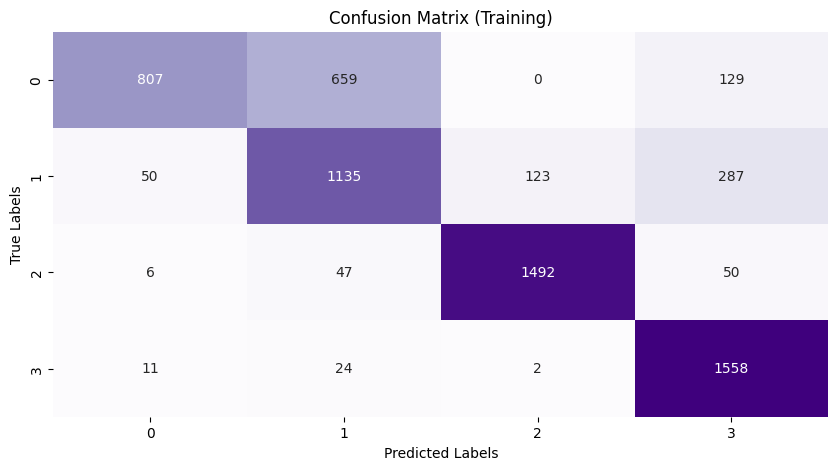

In [19]:
# Making predictions on training data
train_probabilities = model_basline.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating confusion matrix for training data
train_conf_matrix = confusion_matrix(Y_train_resampled, train_predictions)

# Plotting the confusion matrix for training data
plt.figure(figsize=(10, 5))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### X. Testing Metrics


In [20]:
# Evaluatting the model
test_loss, test_accuracy = model_basline.evaluate(X_test, Y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Making predictions on testing data
test_probabilities = model_basline.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

# Generating classification report for testing data
test_report = classification_report(Y_test, test_predictions, target_names=label_mapping.keys())

# Printing the classification report for testing data
print("Classification Report (Testing):\n", test_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7418 - loss: 0.5688
Test Loss: 0.6093710660934448
Test Accuracy: 0.7251908183097839
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Classification Report (Testing):
               precision    recall  f1-score   support

      glioma       0.92      0.38      0.54       146
  meningioma       0.49      0.55      0.52       157
     notumor       0.83      0.92      0.87       207
   pituitary       0.76      0.98      0.86       145

    accuracy                           0.73       655
   macro avg       0.75      0.71      0.70       655
weighted avg       0.75      0.73      0.71       655



200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


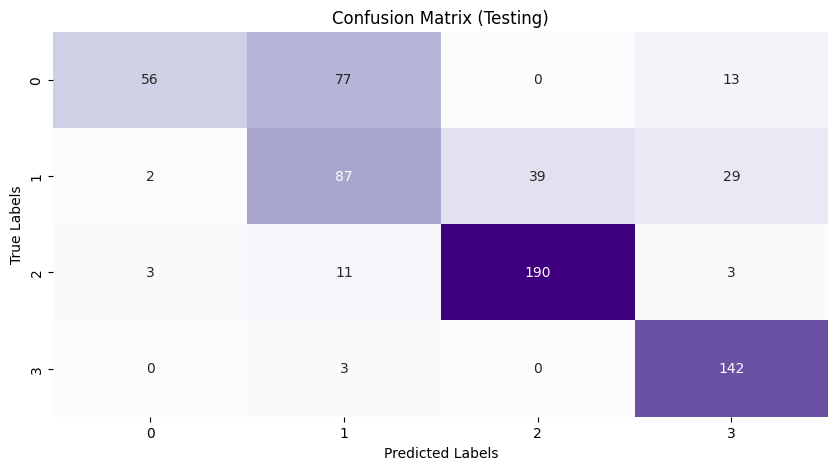

In [22]:
# Making predictions on testing data
test_accuracy_probabilities = model_basline.predict(X_train_resampled)
train_predictions = np.argmax(test_probabilities, axis=1)

# Generating confusion matrix for testing data
test_conf_matrix = confusion_matrix(Y_test, test_predictions)

# Plotting the confusion matrix for testing data
plt.figure(figsize=(10, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix (Testing)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XI. Validation Metrics


In [23]:
# Evaluatting the model
val_loss, val_accuracy = model_basline.evaluate(X_val, Y_val)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

# Making predictions on validation data
val_probabilities = model_basline.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

# Generating classification report for validation data
val_report = classification_report(Y_val, val_predictions, target_names=label_mapping.keys())

# Printing the classification report for validation data
print("Classification Report (Validation):\n", val_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6768 - loss: 0.6594
Validation Loss: 0.6708763837814331
Validation Accuracy: 0.6992366313934326
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Classification Report (Validation):
               precision    recall  f1-score   support

      glioma       0.88      0.33      0.48       153
  meningioma       0.44      0.50      0.47       149
     notumor       0.78      0.93      0.85       198
   pituitary       0.77      0.96      0.85       155

    accuracy                           0.70       655
   macro avg       0.72      0.68      0.66       655
weighted avg       0.72      0.70      0.68       655



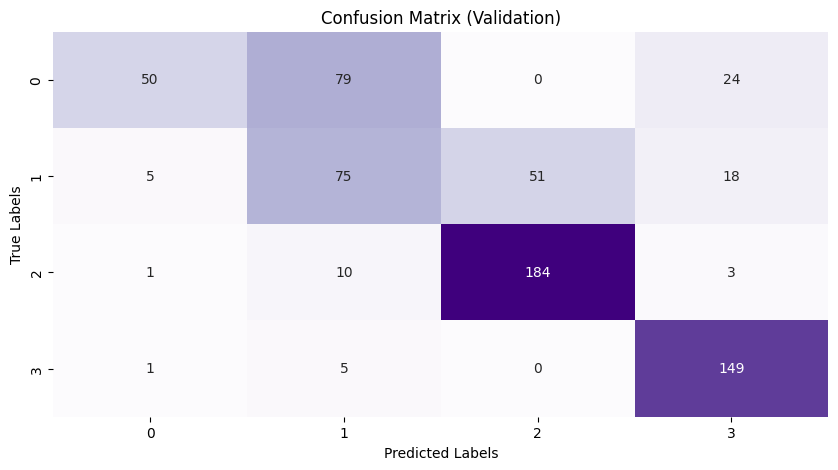

In [24]:
# Generating confusion matrix for validation data
val_conf_matrix = confusion_matrix(Y_val, val_predictions)

# Plotting the confusion matrix for validation data
plt.figure(figsize=(10,5))
plt.style.use('default')
sns.heatmap(val_conf_matrix, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix (Validation)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XII. Graphs

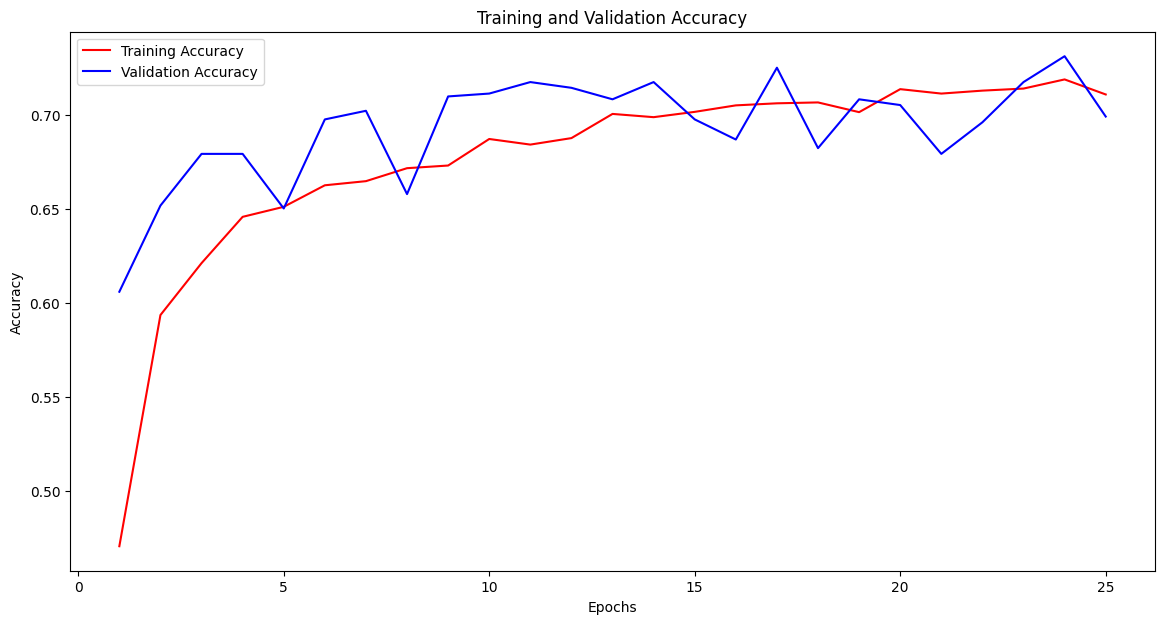

In [26]:
# Extracting the accuracy and validation accuracy from loaded history
acc = history_basline.history['accuracy']
val_acc = history_basline.history['val_accuracy']
epochs = range(1, len(acc) + 1)  

# Plotting the training and validation accuracy
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

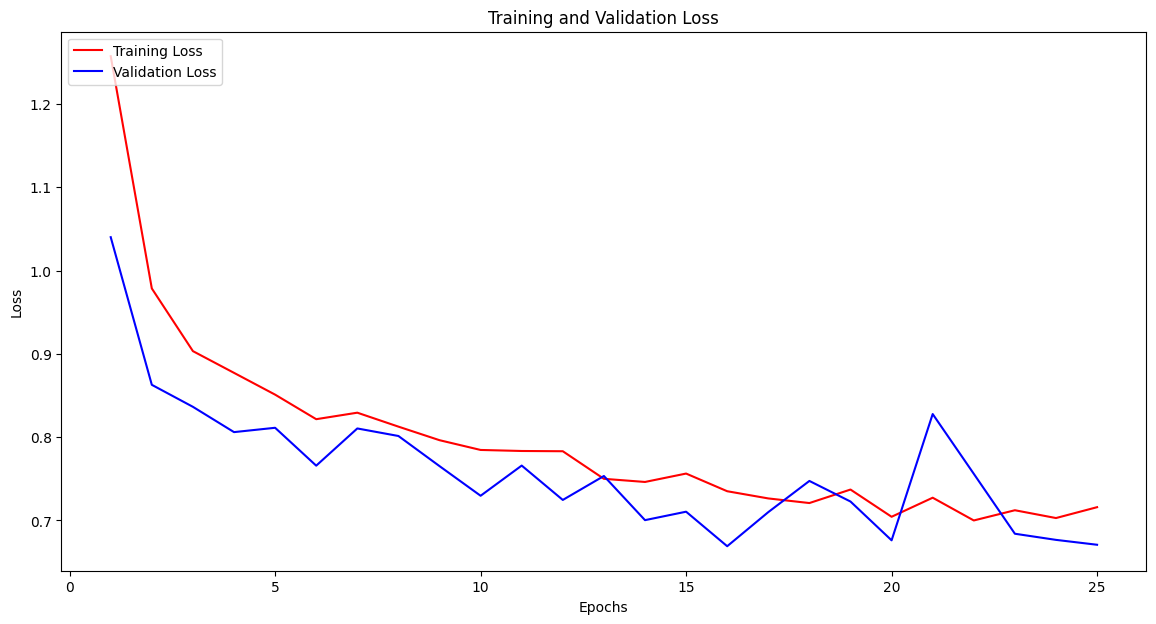

In [27]:
# Extracting the loss and validation loss from loaded history
loss = history_basline.history['loss']
val_loss = history_basline.history['val_loss']
epochs = range(1, len(loss) + 1)  

# Plotting the training and validation loss
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, loss, 'r', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------

### XIII. Final CNN Model

In [10]:
# Define the finilsed CNN model
model = Sequential([
  Conv2D(16, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)),
  MaxPooling2D(2, 2),
  Conv2D(32, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Conv2D(64, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Conv2D(128, (3, 3), activation='relu'),
  MaxPooling2D(2, 2),
  Flatten(),
  Dropout(0.5), 
  Dense(512, activation='relu'),
  Dense(4, activation='softmax') 
])

In [11]:
# Compiling the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Displaying the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,537,188 (36.38 MB)

 Trainable params: 9,537,188 (36.38 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model with data augmentation and the balanced data
history = model.fit(datagen.flow(X_train_resampled, Y_train_resampled, batch_size=32), epochs=100, validation_data=(X_val, Y_val))

Epoch 1/85


c:\Users\Mhd Alkamha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 227ms/step - accuracy: 0.9663 - loss: 0.0982 - val_accuracy: 0.9619 - val_loss: 0.1113
Epoch 2/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step - accuracy: 0.9561 - loss: 0.1136 - val_accuracy: 0.9695 - val_loss: 0.0836
Epoch 3/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 212ms/step - accuracy: 0.9634 - loss: 0.1031 - val_accuracy: 0.9665 - val_loss: 0.0900
Epoch 4/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 212ms/step - accuracy: 0.9710 - loss: 0.0840 - val_accuracy: 0.9771 - val_loss: 0.0603
Epoch 5/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 212ms/step - accuracy: 0.9708 - loss: 0.0844 - val_accuracy: 0.9680 - val_loss: 0.0761
Epoch 6/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 212ms/step - accuracy: 0.9603 - loss: 0.1031 - val_accuracy: 0.9848 - val_loss: 0.0448
Epoch 7/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 215ms/step - accuracy: 0.9684 - loss: 0.0963 - val_accuracy: 0.9817 - val_loss: 0.0501
Epoch 8/85
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 214ms/step - accuracy: 0.9678 - loss: 0.0876 - val

----------------------------------------------------------------------------------------------------------------------------

### XIV. Saving the Finalised CNN Model and Model History

In [27]:
# Save the model
model.save(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\cnn_model_98.h5')

In [9]:
# Loadding the saved model
model = load_model(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\cnn_model_98.h5')

In [29]:
# Saving the model training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\training_history.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [8]:
# Loadding the training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\training_history.pkl', 'rb') as file:
    loaded_history = pickle.load(file)

----------------------------------------------------------------------------------------------------------------------------

### XV. Finalised CNN Training Metrics

In [12]:
# Evaluatting the model
train_loss, train_accuracy = model.evaluate(X_train_resampled, Y_train_resampled)
print("Test Loss:", train_loss)
print("Test Accuracy:", train_accuracy)

# Making predictions on training data
train_probabilities = model.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating classification report for training data
train_report = classification_report(Y_train_resampled, train_predictions, target_names=label_mapping.keys())

# Printing the classification report for training data
print("Classification Report (Training):\n", train_report)

200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9949 - loss: 0.0169
Test Loss: 0.018894707784056664
Test Accuracy: 0.9948275685310364
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
Classification Report (Training):
               precision    recall  f1-score   support

      glioma       1.00      0.99      1.00      1595
  meningioma       0.99      0.99      0.99      1595
     notumor       0.99      1.00      1.00      1595
   pituitary       0.99      0.99      0.99      1595

    accuracy                           0.99      6380
   macro avg       0.99      0.99      0.99      6380
weighted avg       0.99      0.99      0.99      6380



200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step


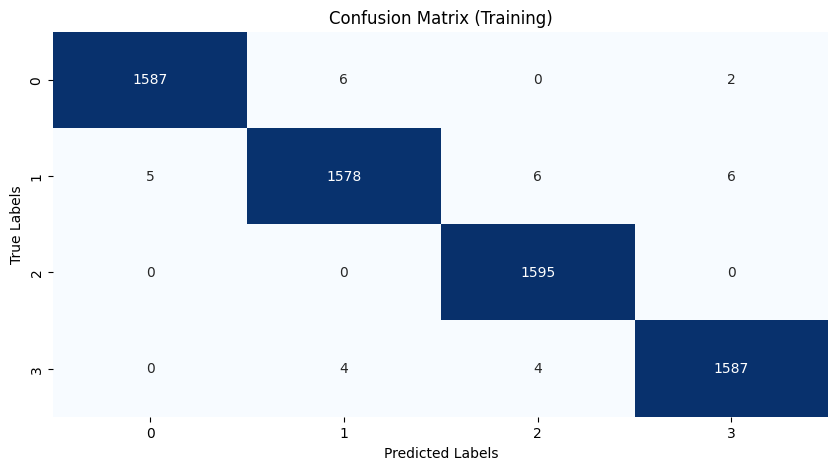

In [13]:
# Making predictions on training data
train_probabilities = model.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating confusion matrix for training data
train_conf_matrix = confusion_matrix(Y_train_resampled, train_predictions)

# Plotting the confusion matrix for training data
plt.figure(figsize=(10, 5))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XVI. Finalised CNN Testing Metrics

In [14]:
# Evaluatting the model
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Making predictions on testing data
test_probabilities = model.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

# Generating classification report for testing data
test_report = classification_report(Y_test, test_predictions, target_names=label_mapping.keys())

# Printing the classification report for testing data
print("Classification Report (Testing):\n", test_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9796 - loss: 0.0847
Test Loss: 0.07205289602279663
Test Accuracy: 0.9786259531974792
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Classification Report (Testing):
               precision    recall  f1-score   support

      glioma       1.00      0.95      0.97       149
  meningioma       0.96      0.96      0.96       148
     notumor       0.98      1.00      0.99       198
   pituitary       0.98      1.00      0.99       160

    accuracy                           0.98       655
   macro avg       0.98      0.98      0.98       655
weighted avg       0.98      0.98      0.98       655



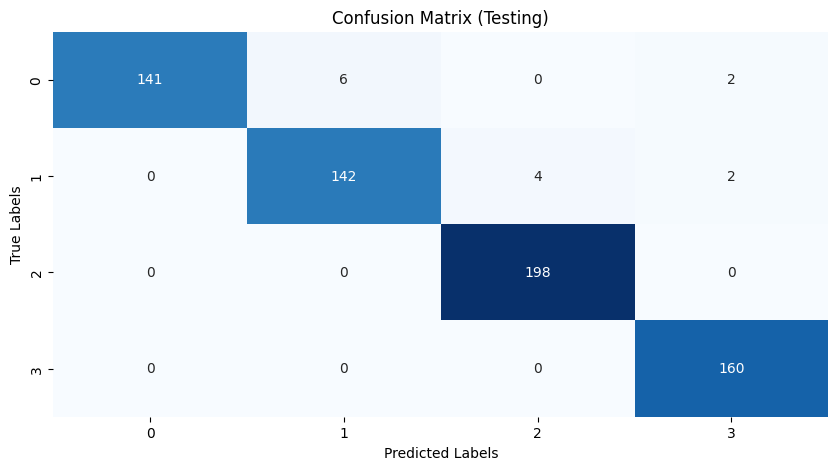

In [15]:
# Making predictions on testing data
test_probabilities = model.predict(X_val)
test_predictions = np.argmax(test_probabilities, axis=1)

# Generating confusion matrix for testing data
test_conf_matrix = confusion_matrix(Y_test, test_predictions)

# Plotting the confusion matrix for testing datatesting data
plt.figure(figsize=(10, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Testing)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XVII. Finalised CNN Validation Metrics


In [16]:
# Evaluatting the model
val_loss, val_accuracy = model.evaluate(X_val, Y_val)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

# Making predictions on validation data
val_probabilities = model.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

# Generating classification report for validation data
val_report = classification_report(Y_val, val_predictions, target_names=label_mapping.keys())

# Printing the classification report for validation data
print("Classification Report (Validation):\n", val_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9946 - loss: 0.0192
Validation Loss: 0.022876640781760216
Validation Accuracy: 0.9908536672592163
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Classification Report (Validation):
               precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       151
  meningioma       0.99      0.98      0.98       158
     notumor       0.99      1.00      1.00       207
   pituitary       0.99      1.00      1.00       140

    accuracy                           0.99       656
   macro avg       0.99      0.99      0.99       656
weighted avg       0.99      0.99      0.99       656



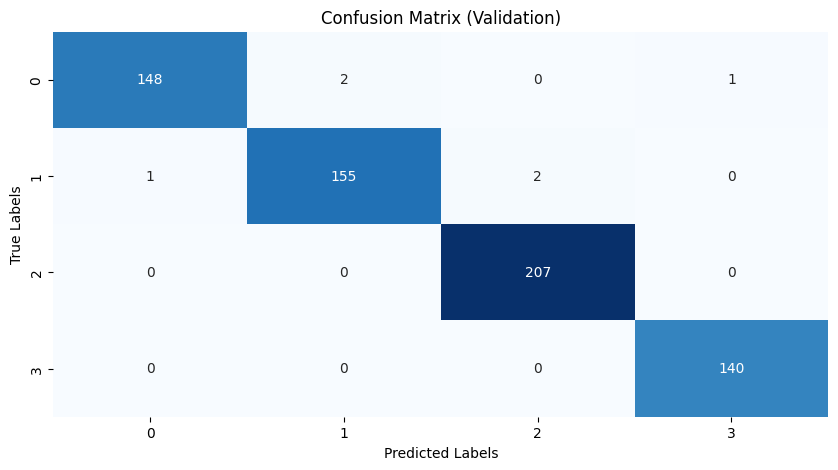

In [17]:
# Making predictions on validation data
val_probabilities = model.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

# Generating confusion matrix for validation data
val_conf_matrix = confusion_matrix(Y_val, val_predictions)

# Plotting the confusion matrix for validation data
plt.figure(figsize=(10,5))
plt.style.use('default')
sns.heatmap(val_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Validation)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XVIII. Finalised CNN Graphs

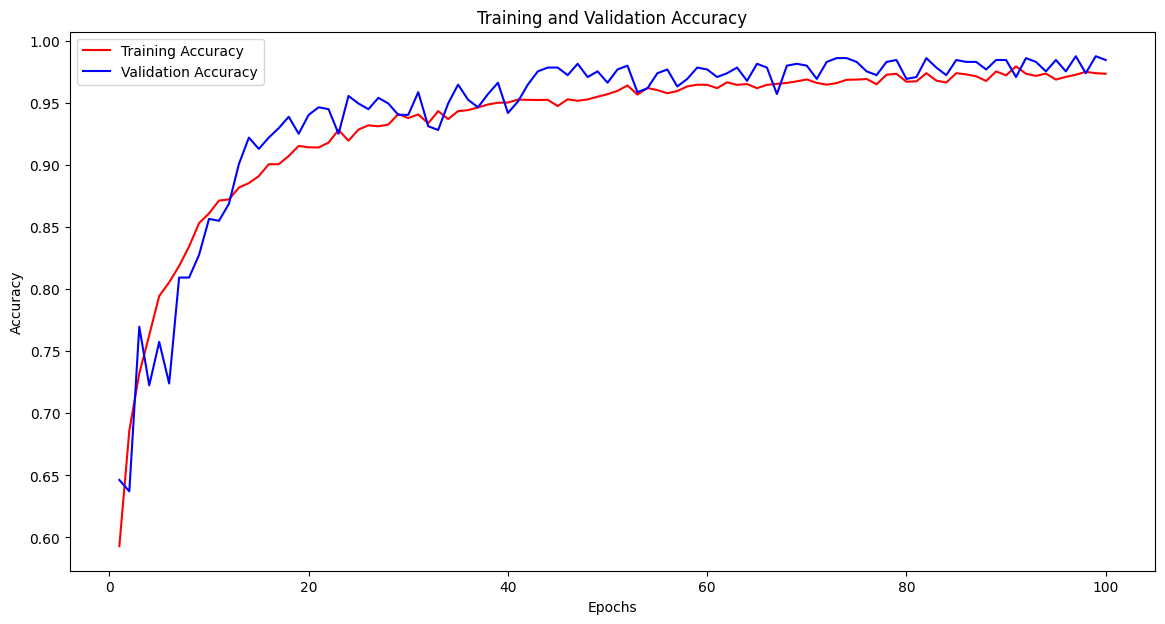

In [19]:
# Extracting the accuracy and validation accuracy from loaded history
acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']
epochs = range(1, len(acc) + 1)  

# Plotting the training and validation accuracy
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

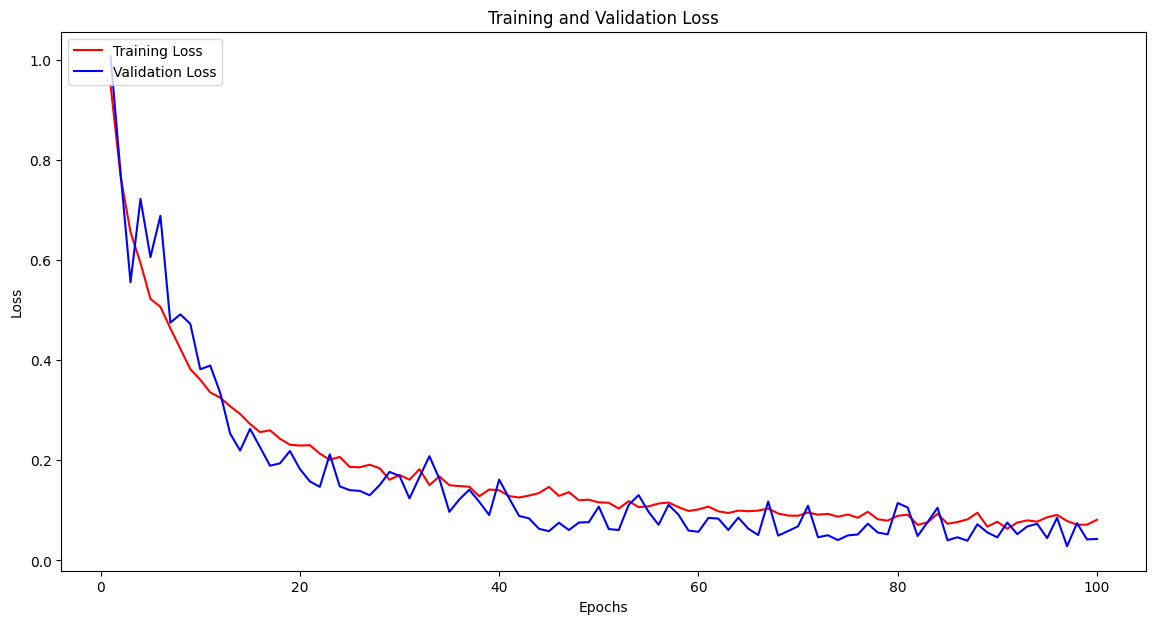

In [20]:
# Extracting the loss and validation loss from loaded history
loss = loaded_history['loss']
val_loss = loaded_history['val_loss']
epochs = range(1, len(loss) + 1)  

# Plotting the training and validation loss
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, loss, 'r', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

### XIX. Testing the Finalised CNN Model on Unseen Data (GUI)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9796 - loss: 0.0847


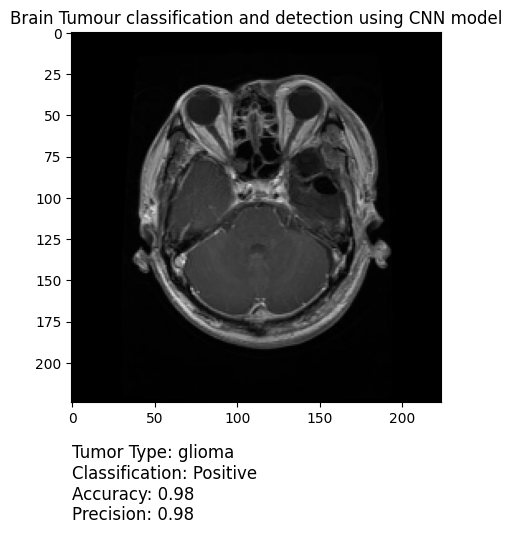

In [27]:
# Invert the label_mapping dictionary
label_mapping = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
label_mapping = {v: k for k, v in label_mapping.items()}


# Function to preprocess the image
def preprocess_image(image_path, image_size):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (image_size, image_size))
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Defining the image path and size
image_path = r'C:\Users\Mhd Alkamha\Desktop\Artifact\MRI_images\Testing\glioma\Te-gl_0011.jpg'
image_size = 224

# Load and preprocess the image
image = preprocess_image(image_path, image_size)

# Make predictions
probabilities = model.predict(image)
predicted_class = np.argmax(probabilities)
predicted_label = label_mapping[predicted_class]


# Determining the classification (positive/negative)
if predicted_class in [0, 1, 3]:
    classification = 'Positive'
else:
    classification = 'Negative'

# Evaluating the model on test data to get accuracy
_, accuracy = model.evaluate(X_test, Y_test)

# Calculating the precision from the classification report
precision = precision_score(Y_test, test_predictions, average='weighted')

# Display the image and classification
plt.imshow(image.squeeze())

plt.title('Brain Tumour classification and detection using CNN model')
plt.text(0, image_size + 25, f'Tumor Type: {predicted_label}\nClassification: {classification}\nAccuracy: {accuracy:.2f}\nPrecision: {precision:.2f}', fontsize=12, color='Black', backgroundcolor='white', verticalalignment='top')

plt.axis('on')
plt.show()

----------------------------------------------------------------------------------------------------------------------------

### XX. VG16 Model


In [29]:
# Load the pre-trained weight file for the VG16 model without the fully connected layers
weights_path = r'C:\Users\Mhd Alkamha\Desktop\Artifact\vg16\vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Load the model
base_model_vgg16 = VGG16(weights=weights_path, include_top=False, input_shape=(image_size, image_size, 3))

In [30]:
# Freeze the layers in the base model
for layer in base_model_vgg16.layers:
    layer.trainable = False

# Creat a new model only with the VGG16 baseline
model_vgg16 = Sequential([
    base_model_vgg16,
    Flatten(),
    Dense(4, activation='softmax')   
])

In [31]:
# Compiling the model
model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Displaying the model summary
model_vgg16.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
# Train the model with data augmentation and the balanced data
history_vgg16 = model_vgg16.fit(datagen.flow(X_train_resampled, Y_train_resampled, batch_size=32), epochs=50, validation_data=(X_val, Y_val))

Epoch 1/50


c:\Users\Mhd Alkamha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.6395 - loss: 0.9465 - val_accuracy: 0.8064 - val_loss: 0.5619
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.8302 - loss: 0.4619 - val_accuracy: 0.8262 - val_loss: 0.5277
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8293 - loss: 0.4776 - val_accuracy: 0.7957 - val_loss: 0.5893
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8632 - loss: 0.3684 - val_accuracy: 0.8537 - val_loss: 0.4337
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8653 - loss: 0.3823 - val_accuracy: 0.8567 - val_loss: 0.4059
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8578 - loss: 0.3743 - val_accuracy: 0.8689 - val_loss: 0.3758
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8563 - loss: 0.3954 - val_accuracy: 0.8399 - val_loss: 0.5838
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8712 - loss: 0.3466 - val_accuracy: 0.876

### XXI. Saving the VGG16 Model and Training History


In [ ]:
# Save the model
model_vgg16.save(r'vgg16_model.h5')

In [ ]:
# Loadding the saved model
model_vgg16 = load_model(r'C:\Users\Mhd Alkamha\Desktop\Artifact\vg16\vgg16_model.h5')

In [34]:
# saving the training history
with open(r'vgg16_training_history.pkl', 'wb') as file:
    pickle.dump(history_vgg16.history, file)

In [89]:
# Loadding the training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\vg16\vgg16_training_history.pkl', 'rb') as file:
    history_vgg16 = pickle.load(file)

----------------------------------------------------------------------------------------------------------------------------

### XXII. VGG16 Training Metric

In [40]:
# Evaluatting the model
vg_train_loss, vg_train_accuracy = model_vgg16.evaluate(X_train_resampled, Y_train_resampled)
print("Test Loss:", vg_train_loss)
print("Test Accuracy:", vg_train_accuracy)

# Making predictions on training data
train_probabilities = model_vgg16.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

label_mapping = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

# Generating classification report for training data
vg_train_report = classification_report(Y_train_resampled, train_predictions, target_names=label_mapping.keys())

# Printing the classification report for training data
print("Classification Report (Training):\n", vg_train_report)

200/200 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9588 - loss: 0.1155
Test Loss: 0.1152590960264206
Test Accuracy: 0.9595611095428467
200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step
Classification Report (Training):
               precision    recall  f1-score   support

      glioma       0.96      0.94      0.95      1595
  meningioma       0.89      0.97      0.93      1595
     notumor       1.00      0.98      0.99      1595
   pituitary       0.99      0.95      0.97      1595

    accuracy                           0.96      6380
   macro avg       0.96      0.96      0.96      6380
weighted avg       0.96      0.96      0.96      6380



200/200 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step


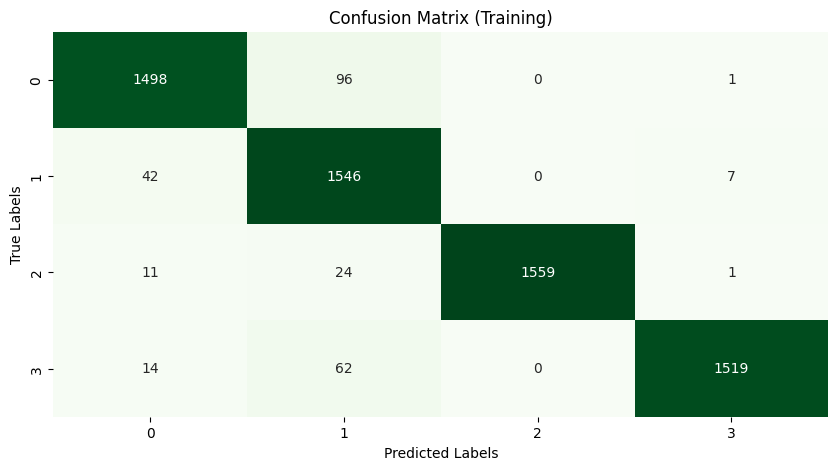

In [44]:
# Making predictions on training data
train_probabilities = model_vgg16.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating confusion matrix for training data
train_conf_matrix = confusion_matrix(Y_train_resampled, train_predictions)

# Plotting the confusion matrix for training data
plt.figure(figsize=(10, 5))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXIII.  VG16 Testing Metrics


In [43]:
# Evaluatting the model
vg_test_loss, vg_test_accuracy = model_vgg16.evaluate(X_test, Y_test)
print("Test Loss:", vg_test_loss)
print("Test Accuracy:", vg_test_accuracy)

# Making predictions on testing data
test_probabilities = model_vgg16.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

label_mapping = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

# Generating classification report for testing data
vg_test_report = classification_report(Y_test, test_predictions, target_names=label_mapping.keys())

# Printing the classification report for testing data
print("Classification Report (Testing):\n", vg_test_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9282 - loss: 0.2815
Test Loss: 0.2542724311351776
Test Accuracy: 0.9236640930175781
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
Classification Report (Testing):
               precision    recall  f1-score   support

      glioma       0.95      0.84      0.89       149
  meningioma       0.77      0.97      0.86       148
     notumor       1.00      0.95      0.98       198
   pituitary       0.99      0.93      0.96       160

    accuracy                           0.92       655
   macro avg       0.93      0.92      0.92       655
weighted avg       0.93      0.92      0.93       655



21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step


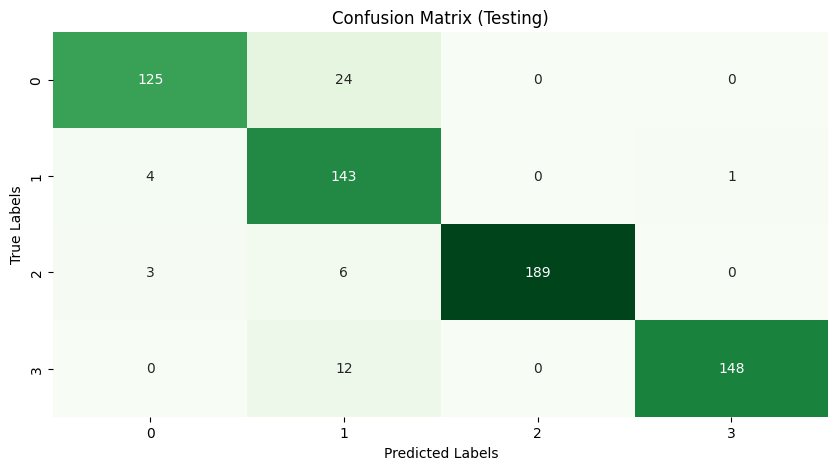

In [46]:
# Making predictions on testing data
test_probabilities = model_vgg16.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

# Generating confusion matrix for testing data
test_conf_matrix = confusion_matrix(Y_test, test_predictions)

# Plotting the confusion matrix for training data
plt.figure(figsize=(10, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Testing)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXIV. VG16 Validation Metrics


In [47]:
# Evaluatting the model
vg_val_loss, vg_val_accuracy = model_vgg16.evaluate(X_val, Y_val)
print("Validation Loss:", vg_val_loss)
print("Validation Accuracy:", vg_val_accuracy)

# Making predictions on validation data
val_probabilities = model_vgg16.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

label_mapping = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

# Generating classification report for validation data
vg_val_report = classification_report(Y_val, val_predictions, target_names=label_mapping.keys())

# Printting the classification report for validation data
print("Classification Report (Validation):\n", vg_val_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9240 - loss: 0.2067
Validation Loss: 0.20405513048171997
Validation Accuracy: 0.9359756112098694
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
Classification Report (Validation):
               precision    recall  f1-score   support

      glioma       0.90      0.89      0.89       151
  meningioma       0.87      0.94      0.90       158
     notumor       0.99      0.96      0.98       207
   pituitary       0.98      0.96      0.97       140

    accuracy                           0.94       656
   macro avg       0.93      0.93      0.93       656
weighted avg       0.94      0.94      0.94       656



21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 999ms/step


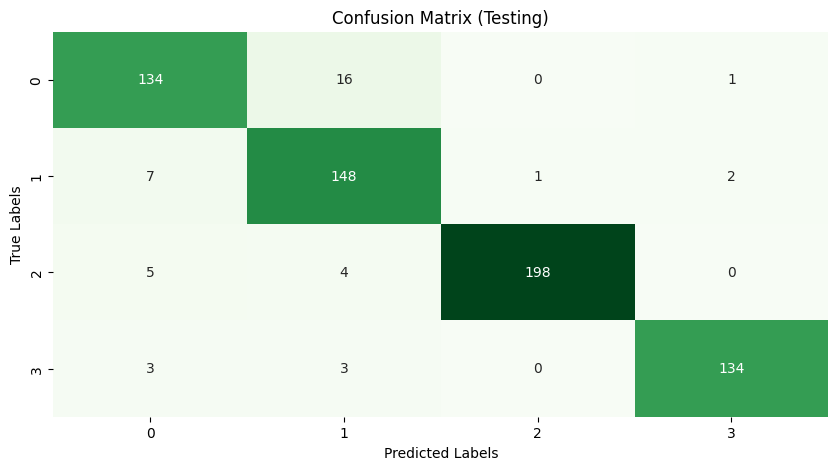

In [49]:
# Making predictions on validation data
val_probabilities = model_vgg16.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)


# Generating confusion matrix for validation data
val_conf_matrix = confusion_matrix(Y_val, val_predictions)

# Plotting the confusion matrix for validation data
plt.figure(figsize=(10, 5))
sns.heatmap(val_conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Testing)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXV. VG16 Graphs

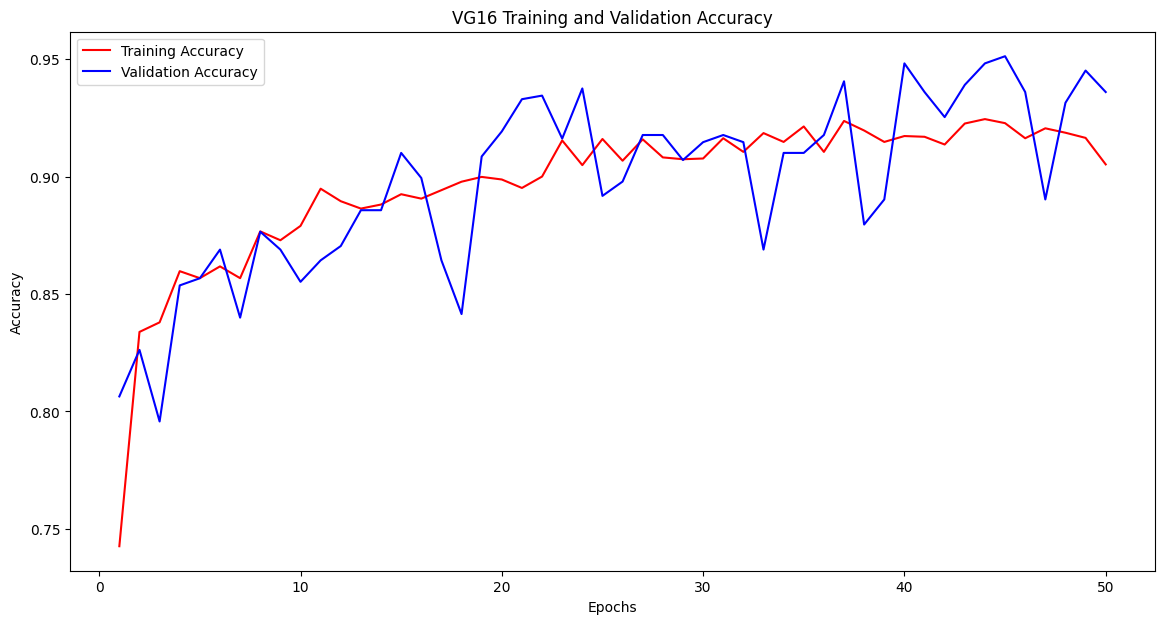

In [51]:
# Extracting the accuracy and validation accuracy from loaded history
acc = history_vgg16.history['accuracy']
val_acc = history_vgg16.history['val_accuracy']
epochs = range(1, len(acc) + 1)  

# Plotting the training and validation accuracy
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('VG16 Training and Validation Accuracy')
plt.show()

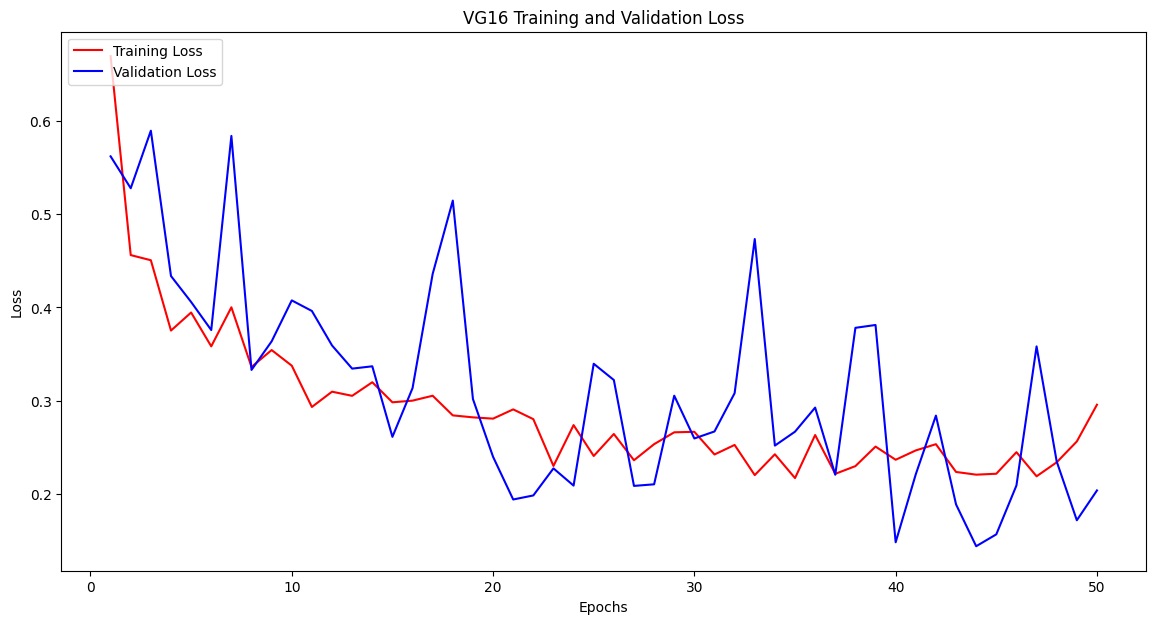

In [52]:
# Extracting the loss and validation loss from loaded history
loss = history_vgg16.history['loss']
val_loss = history_vgg16.history['val_loss']
epochs = range(1, len(loss) + 1)  

# Plotting the training and validation loss
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, loss, 'r', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VG16 Training and Validation Loss')
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------

### XXVI. ResNet50 Model

In [56]:
# Load the pre-trained weight file for the ResNet50 model without the fully connected layers
weights_path = r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Load the model
resnet_base = ResNet50(weights=weights_path, include_top=False, input_shape=(image_size, image_size, 3))

In [57]:
# Freeze the layers in the base model
for layer in resnet_base.layers:
    layer.trainable = False

# Creat a new model only with the ResNet50 baseline
model_rasnet50 = Sequential([
    resnet_base,
    Flatten(),
    Dense(4, activation='softmax')   
])

In [58]:
# Compiling the model
model_rasnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Displaying the model summary
model_rasnet50.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ ?                      │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [59]:
# Train the model with data augmentation and the balanced data
history_rasnet = model_rasnet50.fit(datagen.flow(X_train_resampled, Y_train_resampled, batch_size=32), epochs=50, validation_data=(X_val, Y_val))

Epoch 1/50


c:\Users\Mhd Alkamha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 132s 641ms/step - accuracy: 0.3824 - loss: 2.7050 - val_accuracy: 0.6220 - val_loss: 1.0136
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 135s 669ms/step - accuracy: 0.5462 - loss: 1.1466 - val_accuracy: 0.5777 - val_loss: 1.3455
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 132s 657ms/step - accuracy: 0.5693 - loss: 1.1077 - val_accuracy: 0.6372 - val_loss: 0.9160
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 129s 641ms/step - accuracy: 0.5951 - loss: 1.0863 - val_accuracy: 0.4238 - val_loss: 1.5898
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 128s 636ms/step - accuracy: 0.5686 - loss: 1.2560 - val_accuracy: 0.5854 - val_loss: 1.3876
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 128s 636ms/step - accuracy: 0.6087 - loss: 1.0354 - val_accuracy: 0.6662 - val_loss: 1.0990
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 139s 692ms/step - accuracy: 0.6006 - loss: 1.1097 - val_accuracy: 0.6174 - val_loss: 1.1660
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 156s 767ms/step - accuracy: 0.5994 - loss: 1.19

-----------------------------------------------------------------------------------------------------------------------------------

### XXVII. Saving the ResNet50 Model and Training History


In [ ]:
# Save the model
model_rasnet50.save(r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\rastest_model.h5')

In [ ]:
# Loadding the saved model
model_rasnet50 = load_model(r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\rastest_model.h5')

In [61]:
# Saving the model training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\rasnet50_training_history.pkl', 'wb') as file:
    pickle.dump(history_rasnet.history, file)

In [88]:
# Loadding the training history
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\rasnet50_training_history.pkl', 'rb') as file:
    loaded_history = pickle.load(file)

-----------------------------------------------------------------------------------------------------------------------------------

### XXVIII. ResNet50 Training Metrics


In [62]:
# Evaluatting the model
rasnet_train_loss, rasnet_train_accuracy = model_rasnet50.evaluate(X_train_resampled, Y_train_resampled)
print("Test Loss:", rasnet_train_loss)
print("Test Accuracy:", rasnet_train_accuracy)

# Making predictions on training data
train_probabilities = model_rasnet50.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating classification report for training data
rasnet_train_report = classification_report(Y_train_resampled, train_predictions, target_names=label_mapping.keys())

# Printing the classification report for training data
print("Classification Report (Training):\n", rasnet_train_report)

200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 400ms/step - accuracy: 0.6517 - loss: 1.2832
Test Loss: 1.3197951316833496
Test Accuracy: 0.6390281915664673
200/200 ━━━━━━━━━━━━━━━━━━━━ 116s 576ms/step
Classification Report (Training):
               precision    recall  f1-score   support

      glioma       0.70      0.62      0.66      1595
  meningioma       0.90      0.17      0.28      1595
     notumor       0.94      0.77      0.85      1595
   pituitary       0.47      1.00      0.64      1595

    accuracy                           0.64      6380
   macro avg       0.75      0.64      0.61      6380
weighted avg       0.75      0.64      0.61      6380



200/200 ━━━━━━━━━━━━━━━━━━━━ 105s 527ms/step


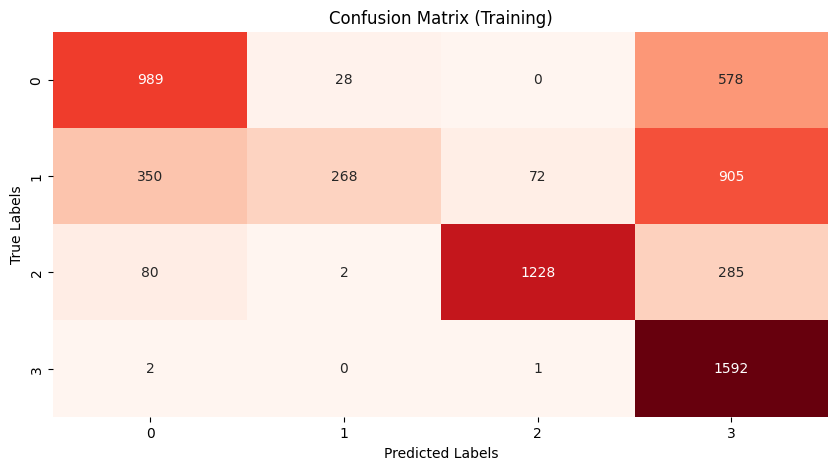

In [66]:
# Making predictions on training data
train_probabilities = model_rasnet50.predict(X_train_resampled)
train_predictions = np.argmax(train_probabilities, axis=1)

# Generating confusion matrix for training data
train_conf_matrix = confusion_matrix(Y_train_resampled, train_predictions)

# Plotting the confusion matrix for training data
plt.figure(figsize=(10, 5))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXIX. ResNet50 Testing Metrics

In [67]:
# Evaluatting the model
rasnet_test_loss, rasnet_test_accuracy = model_rasnet50.evaluate(X_test, Y_test)
print("Test Loss:", rasnet_test_loss)
print("Test Accuracy:", rasnet_test_accuracy)

# Making predictions on testing data
test_probabilities = model_rasnet50.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

# Generating classification report for testing data
rasnet_test_report = classification_report(Y_test, test_predictions, target_names=label_mapping.keys())

# Printing the classification report for testing data
print("Classification Report (Testing):\n", rasnet_test_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 465ms/step - accuracy: 0.6418 - loss: 1.4206
Test Loss: 1.5176771879196167
Test Accuracy: 0.6274809241294861
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 563ms/step
Classification Report (Testing):
               precision    recall  f1-score   support

      glioma       0.71      0.48      0.57       149
  meningioma       0.84      0.21      0.34       148
     notumor       0.85      0.75      0.79       198
   pituitary       0.47      1.00      0.64       160

    accuracy                           0.63       655
   macro avg       0.71      0.61      0.59       655
weighted avg       0.72      0.63      0.60       655



21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step


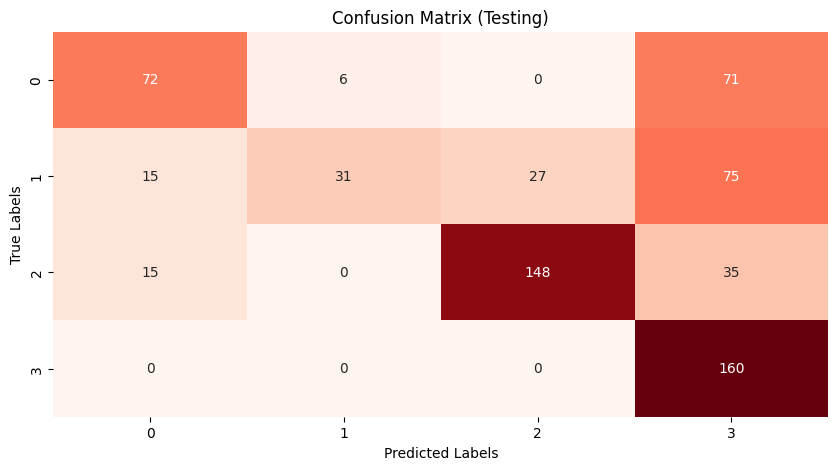

In [77]:
# Make predictions on test data
test_probabilities = model_rasnet50.predict(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)

# Calculate confusion matrix for test data
test_conf_matrix = confusion_matrix(Y_test, test_predictions)

# Plotting the confusion matrix for testing datatest data
plt.figure(figsize=(10, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix (Testing)')  # Updated title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXX. ResNet50 Validation Metrics


In [71]:
# Evaluatting the model
rasnet_val_loss, rasnet_val_accuracy = model_rasnet50.evaluate(X_val, Y_val)
print("Validation Loss:", rasnet_val_loss)
print("Validation Accuracy:", rasnet_val_accuracy)

# Making predictions on validation data
val_probabilities = model_rasnet50.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

# Generating classification report for validation data
rasnet_val_report = classification_report(Y_val, val_predictions, target_names=label_mapping.keys())

# Printing the classification report for validation data
print("Classification Report (Validation):\n", rasnet_val_report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 539ms/step - accuracy: 0.6131 - loss: 1.6396
Validation Loss: 1.7488455772399902
Validation Accuracy: 0.5899389982223511
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 863ms/step
Classification Report (Validation):
               precision    recall  f1-score   support

      glioma       0.66      0.48      0.56       151
  meningioma       0.78      0.11      0.20       158
     notumor       0.83      0.75      0.79       207
   pituitary       0.42      1.00      0.59       140

    accuracy                           0.59       656
   macro avg       0.67      0.59      0.53       656
weighted avg       0.69      0.59      0.55       656



21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 453ms/step


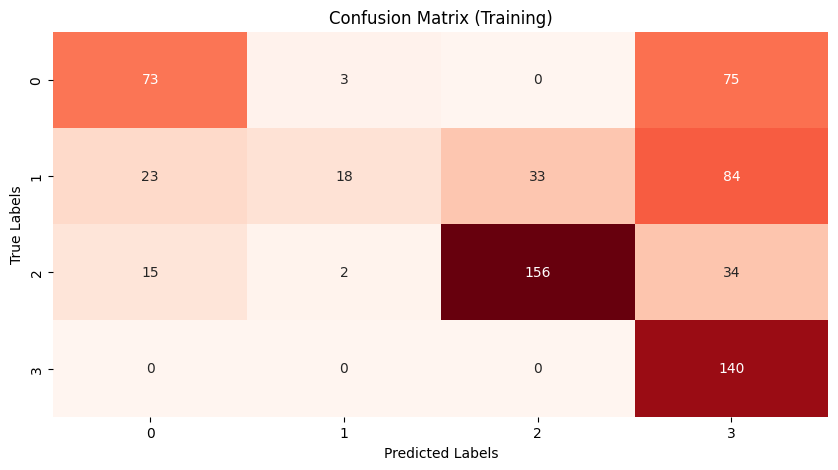

In [78]:
# Making predictions on validation data
val_probabilities = model_rasnet50.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

# Generating confusion matrix for validation data
val_conf_matrix = confusion_matrix(Y_val, val_predictions)

# Plotting the confusion matrix for validation data
plt.figure(figsize=(10, 5))
sns.heatmap(val_conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix (Training)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### XXXI. ResNet50 Graphs


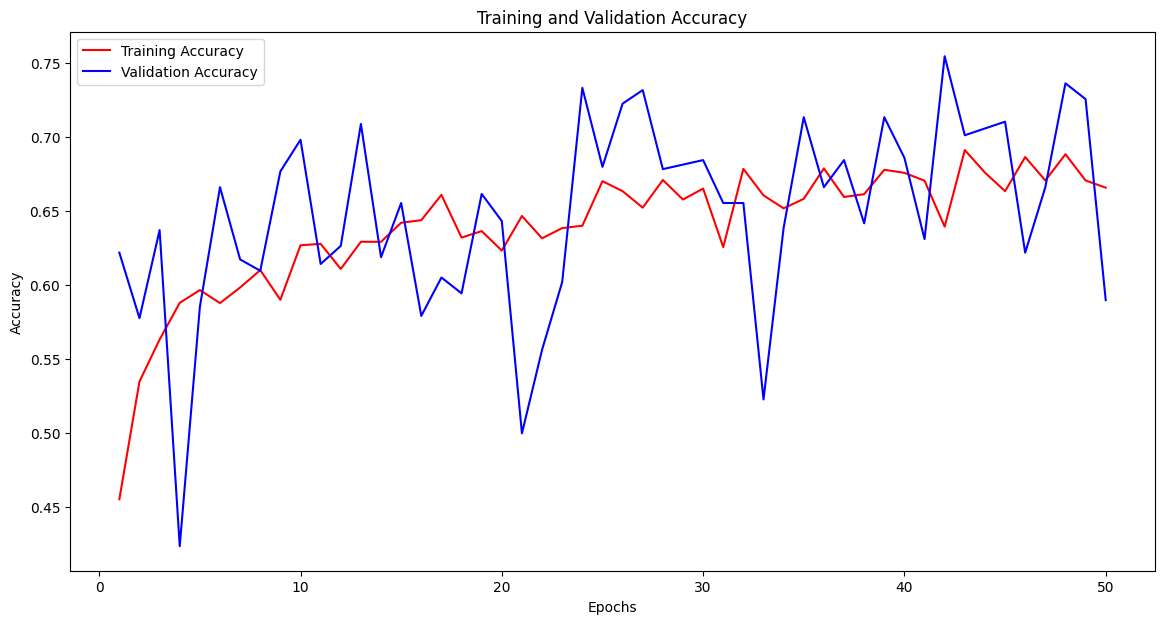

In [80]:
# Extracting the accuracy and validation accuracy from loaded history
acc = history_rasnet.history['accuracy']    
val_acc = history_rasnet.history['val_accuracy']    
epochs = range(1, len(acc) + 1)  

# Plotting the training and validation accuracy
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

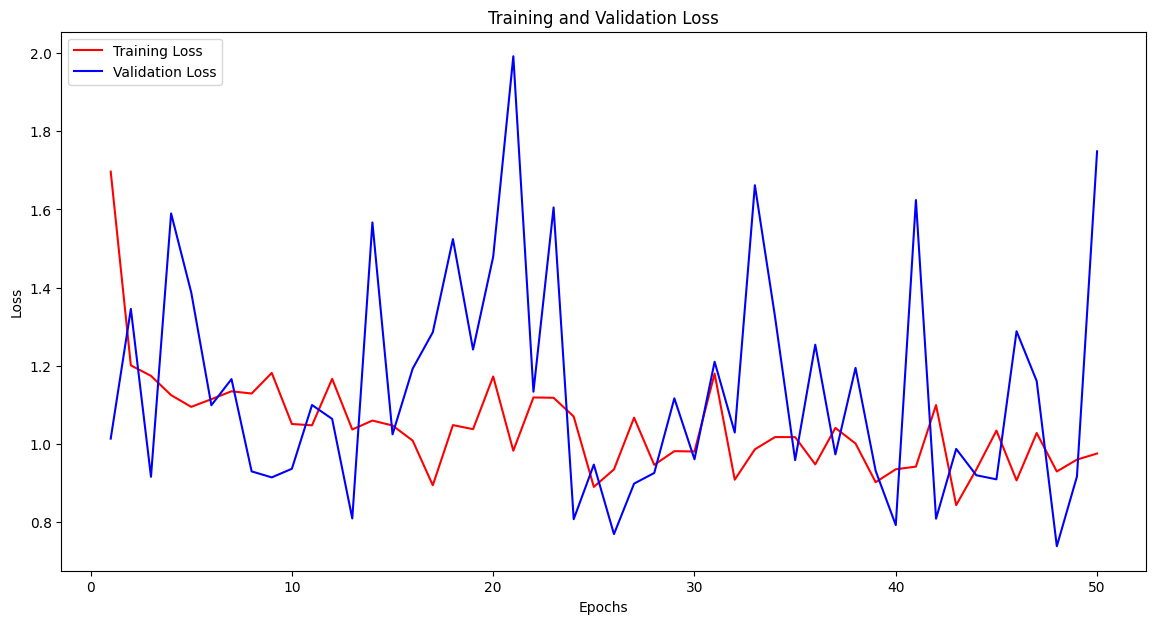

In [81]:
# Extracting the loss and validation loss from loaded history
loss = history_rasnet.history['loss']
val_loss = history_rasnet.history['val_loss']
epochs = range(1, len(loss) + 1)  

# Plotting the training and validation loss
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, loss, 'r', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

-------------------------------------------------------------------------------------------------------------------

### XXXII. Further Evaluation of All Models Through Graphs

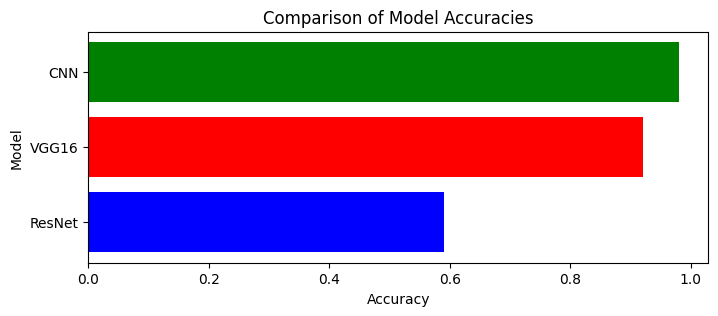

In [23]:
# Defining the model names
models = ['ResNet', 'VGG16', 'CNN'] 

# Accuracy achieved by each model
accuracies = [0.59, 0.92, 0.98]  

# Plotting the values
plt.figure(figsize=(8, 3))
plt.barh(models, accuracies, color=['blue', 'red', 'green']) 
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Comparison of Model Accuracies')
plt.show()

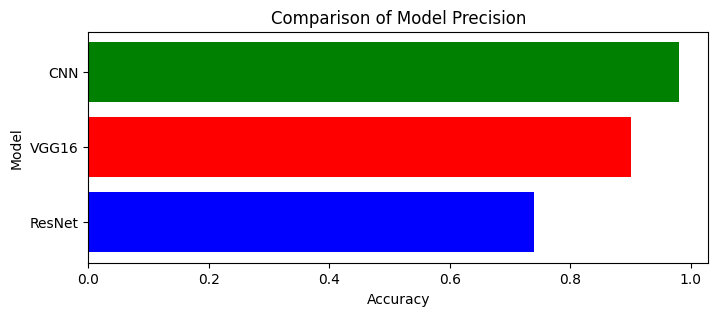

In [24]:
# Defining the model names
models = ['ResNet', 'VGG16', 'CNN']

# Precision achieved by each model
accuracies = [0.74, 0.90, 0.98]  

# Plotting the values
plt.figure(figsize=(8, 3))
plt.barh(models, accuracies, color=['blue', 'red', 'green']) 
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Comparison of Model Precision')
plt.show()

In [18]:
# Loadding the training history for ResNet
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\resnet50\rasnet50_training_history.pkl', 'rb') as file:
    history_resnet = pickle.load(file)

# Loadding the training history for VGG16
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\vg16\vgg16_training_history.pkl', 'rb') as file:
    history_vgg16 = pickle.load(file)

# Loadding the training history for CNN
with open(r'C:\Users\Mhd Alkamha\Desktop\Artifact\CNN_Modle\training_history.pkl', 'rb') as file:
    history_cnn = pickle.load(file)

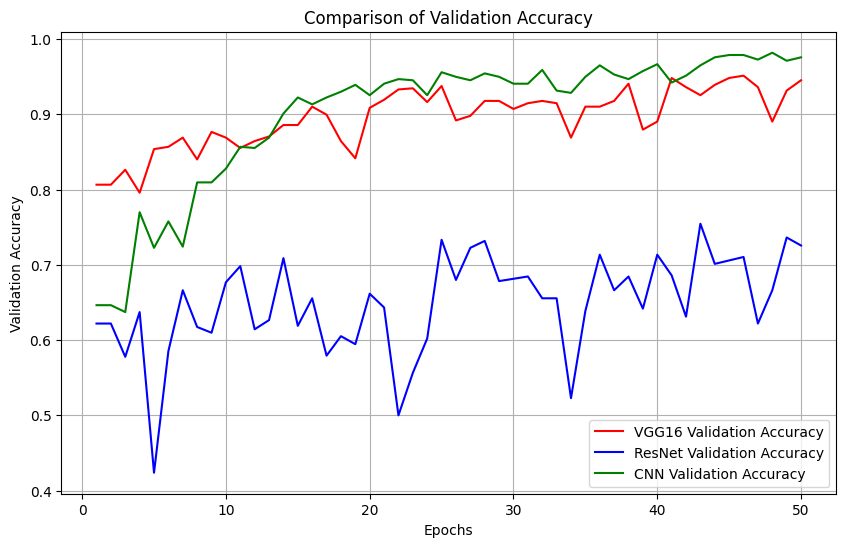

In [19]:
# # Extracting the validation accuracy from the ResNet50 history
vgg16_val_acc = history_vgg16['val_accuracy']

# Extract validation accuracy from history for ResNet50
resnet_val_acc = history_resnet['val_accuracy']

# Extracting the validation accuracy from the CNN historyN
cnn_val_acc = history_cnn['val_accuracy']

# Finding the minimum number of epochs among all models
min_epochs = min(len(vgg16_val_acc), len(resnet_val_acc), len(cnn_val_acc))

# Reading the accuracy values for each model to match the minimum number of epochs
vgg16_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(vgg16_val_acc) + 1), vgg16_val_acc)
resnet_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(resnet_val_acc) + 1), resnet_val_acc)
cnn_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(cnn_val_acc) + 1), cnn_val_acc)

# Plotting the validation accuracy for each model
plt.figure(figsize=(10, 6))
plt.plot(range(1, min_epochs + 1), vgg16_val_acc_interp, 'r', label='VGG16 Validation Accuracy')
plt.plot(range(1, min_epochs + 1), resnet_val_acc_interp, 'b', label='ResNet Validation Accuracy')
plt.plot(range(1, min_epochs + 1), cnn_val_acc_interp, 'g', label='CNN Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

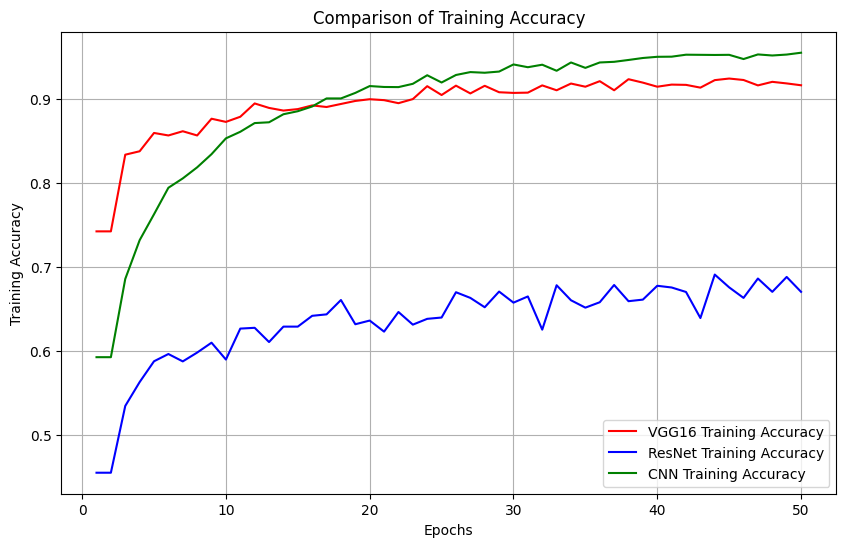

In [22]:
# # Extracting the validation accuracy from the ResNet50 history
vgg16_val_acc = history_vgg16['accuracy']

# Extracting the validation accuracy from the ResNet50 history
resnet_val_acc = history_resnet['accuracy']

# Extracting the validation accuracy from the CNN history
cnn_val_acc = history_cnn['accuracy']

# Finding the minimum number of epochs among all models
min_epochs = min(len(vgg16_val_acc), len(resnet_val_acc), len(cnn_val_acc))

# Reading the accuracy values for each model to match the minimum number of epochs
vgg16_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(vgg16_val_acc) + 1), vgg16_val_acc)
resnet_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(resnet_val_acc) + 1), resnet_val_acc)
cnn_val_acc_interp = np.interp(np.arange(min_epochs), range(1, len(cnn_val_acc) + 1), cnn_val_acc)

# Plotting the validation accuracy for each model
plt.figure(figsize=(10, 6))
plt.plot(range(1, min_epochs + 1), vgg16_val_acc_interp, 'r', label='VGG16 Training Accuracy')
plt.plot(range(1, min_epochs + 1), resnet_val_acc_interp, 'b', label='ResNet Training Accuracy')
plt.plot(range(1, min_epochs + 1), cnn_val_acc_interp, 'g', label='CNN Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Comparison of Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

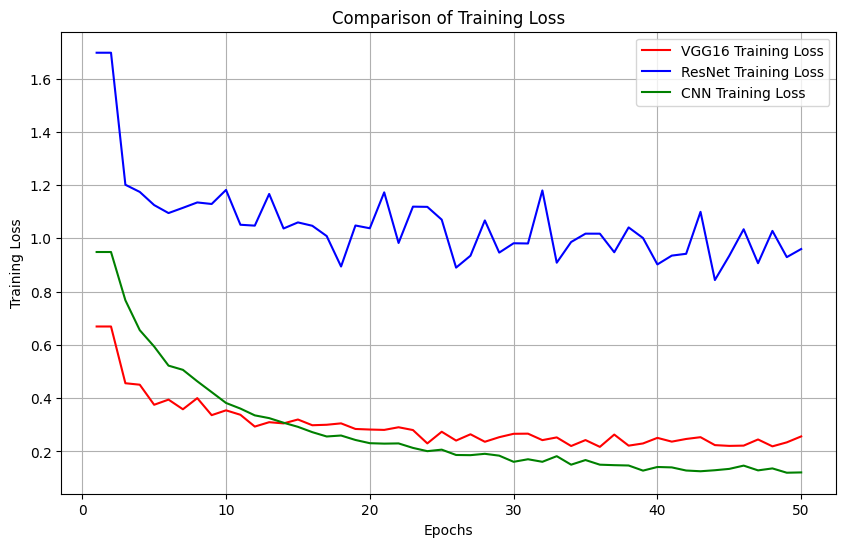

In [20]:
# Extract training loss from history for VGG16
vgg16_loss = history_vgg16['loss']

# Extract training loss from history for ResNet
resnet_loss = history_resnet['loss']

# Extract training loss from history for CNN
cnn_loss = history_cnn['loss']

# Finding the minimum number of epochs among all models
min_epochs = min(len(vgg16_loss), len(resnet_loss), len(cnn_loss))

# Reading the loss values for each model to match the minimum number of epochs
vgg16_loss_interp = np.interp(np.arange(min_epochs), range(1, len(vgg16_loss) + 1), vgg16_loss)
resnet_loss_interp = np.interp(np.arange(min_epochs), range(1, len(resnet_loss) + 1), resnet_loss)
cnn_loss_interp = np.interp(np.arange(min_epochs), range(1, len(cnn_loss) + 1), cnn_loss)

# Plotting the training loss for each model
plt.figure(figsize=(10, 6))
plt.plot(range(1, min_epochs + 1), vgg16_loss_interp, 'r', label='VGG16 Training Loss')
plt.plot(range(1, min_epochs + 1), resnet_loss_interp, 'b', label='ResNet Training Loss')
plt.plot(range(1, min_epochs + 1), cnn_loss_interp, 'g', label='CNN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Comparison of Training Loss')
plt.legend()
plt.grid(True)
plt.show()

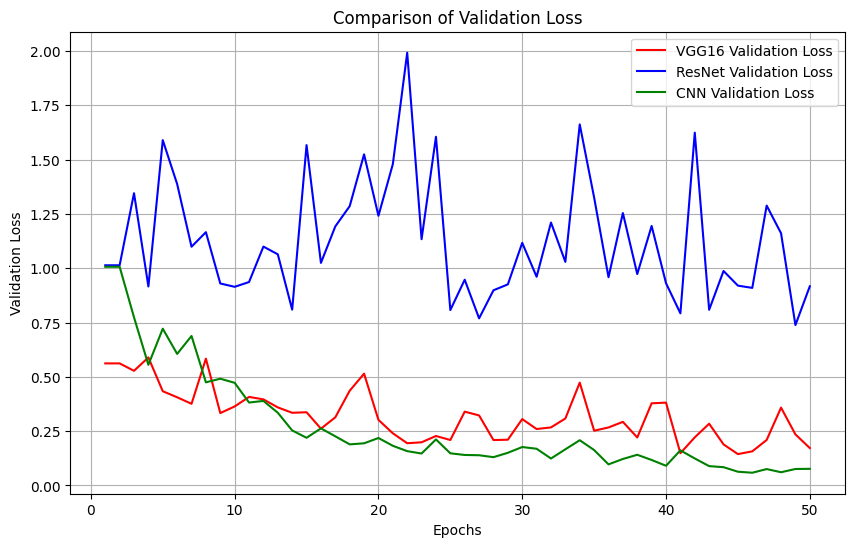

In [21]:
# Extract validation loss from history for VGG16
vgg16_val_loss = history_vgg16['val_loss']

# Extract validation loss from history for ResNet
resnet_val_loss = history_resnet['val_loss']

# Extract validation loss from history for CNN
cnn_val_loss = history_cnn['val_loss']

# Finding the minimum number of epochs among all models
min_epochs = min(len(vgg16_val_loss), len(resnet_val_loss), len(cnn_val_loss))

# Reading the loss values for each model to match the minimum number of epochs
vgg16_val_loss_interp = np.interp(np.arange(min_epochs), range(1, len(vgg16_val_loss) + 1), vgg16_val_loss)
resnet_val_loss_interp = np.interp(np.arange(min_epochs), range(1, len(resnet_val_loss) + 1), resnet_val_loss)
cnn_val_loss_interp = np.interp(np.arange(min_epochs), range(1, len(cnn_val_loss) + 1), cnn_val_loss)

# Plotting the validation loss for each model
plt.figure(figsize=(10, 6))
plt.plot(range(1, min_epochs + 1), vgg16_val_loss_interp, 'r', label='VGG16 Validation Loss')
plt.plot(range(1, min_epochs + 1), resnet_val_loss_interp, 'b', label='ResNet Validation Loss')
plt.plot(range(1, min_epochs + 1), cnn_val_loss_interp, 'g', label='CNN Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Comparison of Validation Loss')
plt.legend()
plt.grid(True)
plt.show()